In [1]:
from datetime import datetime, timedelta
import numpy as np
from numpyDatabase import DataStore

In [21]:

# ---------------------------------------------------------
# Paste or import your DataStore class here
# ---------------------------------------------------------
# from datastore_numpy import DataStore


resolution = timedelta(minutes=15)

db = DataStore(
    resolution=resolution,
    initial_capacity=10
)

now_time = datetime(2026, 1, 1, 0, 0)

# -----------------------------------------------------
# Simulate 24 hours of data
# -----------------------------------------------------
n_steps = 24 * 4  # 24 hours x 4 samples/hour

battery_soc = 0.50


In [22]:
for i in range(n_steps):
    now_time = now_time + resolution

    demand_kw = 2.0 + 0.5 * np.sin(i / 5)
    pv_kw = max(0.0, 3.0 * np.sin((i - 24) / 20))
    battery_power_kw = -0.5 if pv_kw > demand_kw else 0.5

    battery_soc = battery_soc - battery_power_kw * 0.01
    battery_soc = max(0.2, min(1.0, battery_soc))

    net_power_kw = demand_kw - pv_kw + battery_power_kw
    row = {
            "Demand Electric Power (kW)": demand_kw,
            "PV Electric Power (kW)": pv_kw,
            "Battery Electric Power (kW)": battery_power_kw,
            "Battery SOC (-)": battery_soc,
            "Total Electric Power (kW)": net_power_kw,
        }
    db.append(
        now_time,
        row
    )


In [23]:
df_new = db.to_pandas()

In [24]:
df_new

,Demand Electric Power (kW),PV Electric Power (kW),Battery Electric Power (kW),Battery SOC (-),Total Electric Power (kW)
time,,,,,
2026-01-01 00:15:00,2.000000,0.0,0.5,0.495,2.500000
2026-01-01 00:30:00,2.099335,0.0,0.5,0.490,2.599335
2026-01-01 00:45:00,2.194709,0.0,0.5,0.485,2.694709
2026-01-01 01:00:00,2.282321,0.0,0.5,0.480,2.782321
2026-01-01 01:15:00,2.358678,0.0,0.5,0.475,2.858678
...,...,...,...,...,...
2026-01-01 23:00:00,1.697584,0.0,0.5,0.290,2.197584
2026-01-01 23:15:00,1.782717,0.0,0.5,0.285,2.282717
2026-01-01 23:30:00,1.876513,0.0,0.5,0.280,2.376513


In [27]:
# -----------------------------------------------------
# Test 1: get latest state
# -----------------------------------------------------
latest = db.get_instant_state(
    [
        "Demand Electric Power (kW)",
        "PV Electric Power (kW)",
        "Battery SOC (-)",
    ]
)

print("\nLatest state:")
print(latest)



Latest state:
{'Demand Electric Power (kW)': 2.0749385, 'PV Electric Power (kW)': 0.0, 'Battery SOC (-)': 0.27}


In [26]:
# -----------------------------------------------------
# Test 2: get state at a specific time
# -----------------------------------------------------
query_time = datetime(2026, 1, 1, 1, 00)

state_at_time = db.get_instant_state(
    [
        "Demand Electric Power (kW)",
        "PV Electric Power (kW)",
        "Battery SOC (-)",
        "Total Electric Power (kW)",
    ],
    now_time=query_time
)

print(f"\nState at {query_time}:")
print(state_at_time)

# Since 06:10 is between 06:00 and 06:15,
# it should return the 06:00 row.



State at 2026-01-01 01:00:00:
{'Demand Electric Power (kW)': 2.2823212, 'PV Electric Power (kW)': 0.0, 'Battery SOC (-)': 0.48, 'Total Electric Power (kW)': 2.7823212}


In [6]:
# -----------------------------------------------------
# Test 3: convert to pandas for visualisation
# -----------------------------------------------------
df = db.to_pandas()

print("\nPandas DataFrame head:")
print(df.head())

print("\nPandas DataFrame tail:")
print(df.tail())

print("\nDataFrame info:")
print(df.info())


Pandas DataFrame head:
                     Demand Electric Power (kW)  PV Electric Power (kW)  \
time                                                                      
2026-01-01 00:00:00                    2.000000                     0.0   
2026-01-01 00:15:00                    2.099335                     0.0   
2026-01-01 00:30:00                    2.194709                     0.0   
2026-01-01 00:45:00                    2.282321                     0.0   
2026-01-01 01:00:00                    2.358678                     0.0   

                     Battery Electric Power (kW)  Battery SOC (-)  \
time                                                                
2026-01-01 00:00:00                          0.5            0.495   
2026-01-01 00:15:00                          0.5            0.490   
2026-01-01 00:30:00                          0.5            0.485   
2026-01-01 00:45:00                          0.5            0.480   
2026-01-01 01:00:00                 

In [10]:
df

,Demand Electric Power (kW),PV Electric Power (kW),Battery Electric Power (kW),Battery SOC (-),Total Electric Power (kW)
time,,,,,
2026-01-01 00:00:00,2.000000,0.0,0.5,0.495,2.500000
2026-01-01 00:15:00,2.099335,0.0,0.5,0.490,2.599335
2026-01-01 00:30:00,2.194709,0.0,0.5,0.485,2.694709
2026-01-01 00:45:00,2.282321,0.0,0.5,0.480,2.782321
2026-01-01 01:00:00,2.358678,0.0,0.5,0.475,2.858678
...,...,...,...,...,...
2026-01-01 22:45:00,1.697584,0.0,0.5,0.290,2.197584
2026-01-01 23:00:00,1.782717,0.0,0.5,0.285,2.282717
2026-01-01 23:15:00,1.876513,0.0,0.5,0.280,2.376513


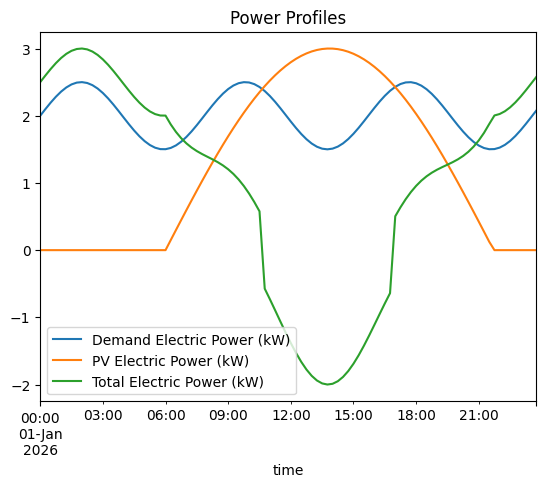

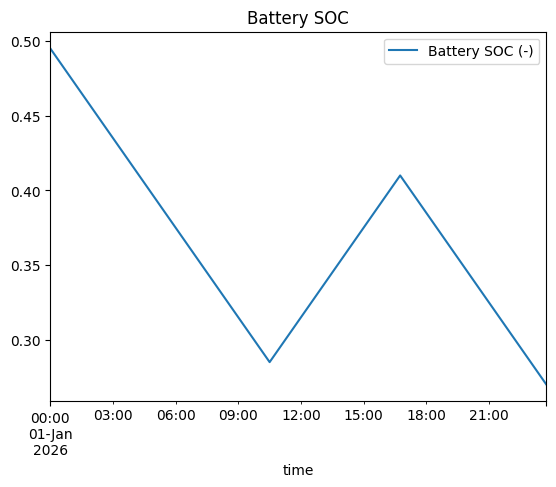


Saved output to datastore_test_output.csv


In [7]:
# -----------------------------------------------------
# Test 4: simple plot
# -----------------------------------------------------
df[
    [
        "Demand Electric Power (kW)",
        "PV Electric Power (kW)",
        "Total Electric Power (kW)",
    ]
].plot(
    title="Power Profiles"
)

df[
    [
        "Battery SOC (-)"
    ]
].plot(
    title="Battery SOC"
)

import matplotlib.pyplot as plt
plt.show()

# -----------------------------------------------------
# Test 5: save result
# -----------------------------------------------------
df.to_csv("datastore_test_output.csv")
print("\nSaved output to datastore_test_output.csv")